# Pose

In [7]:
import aruco
import cv2
!pip install -qq git+https://github.com/udesa-vision/i308-utils.git

from i308_utils import imshow, show_images

In [8]:
use_dict = cv2.aruco.DICT_6X6_250
squares_x=5
squares_y=7
square_length=52.6
marker_length=31.3


board = aruco.create_charuco_board(
    squares_x,
    squares_y,
    square_length,
    marker_length,
    use_dict
)

img1 = cv2.imread("data/rectified/001_left_0_rect.png")
img2 = cv2  .imread("data/rectified/002_left_1_rect.png")


In [ ]:
import pickle, os
with open(os.path.join("data","stereo_calibration.pkl"), "rb") as f:
    c = pickle.load(f)
calibration = (c["left_K"], c["left_dist"])  
K, dist = calibration

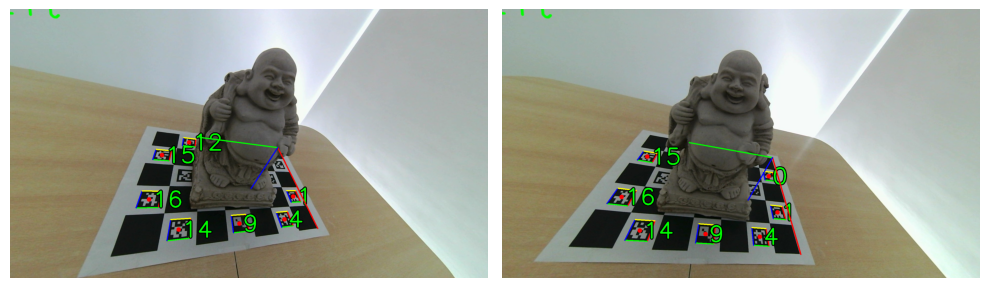

In [ ]:
results = []
    
for img in [img1, img2]:

    detection = aruco.detect_charuco_markers(img, board)

    pose = aruco.estimate_camera_pose_with_homography(
        img, board, detection, calibration,
    )
    ok, rv, tv = pose
    
    result_img = aruco.draw_aruco_results(
        img, detection, size=3
    )
    cv2.drawFrameAxes(result_img, K, dist, rv, tv, square_length * 5)
    results.append(result_img) 
    

show_images(results)

# Visualizar 21 cámaras con VO (ORB + Essential + recoverPose)

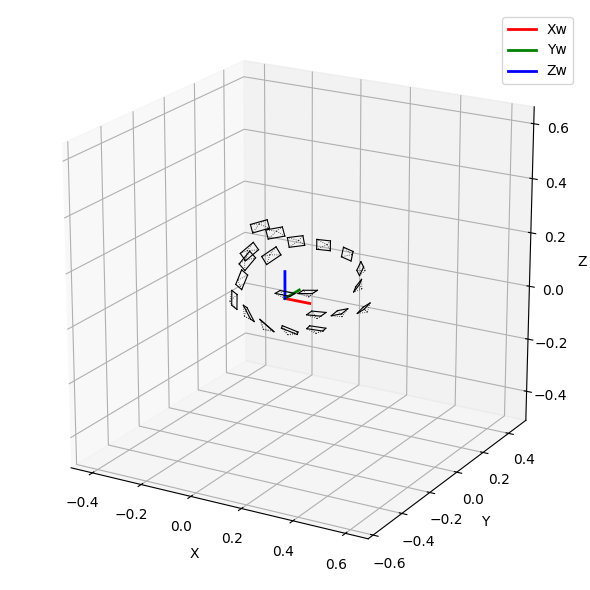

In [ ]:
import os, glob, pickle
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

with open(os.path.join("data","stereo_calibration.pkl"), "rb") as f:
    cal = pickle.load(f)
K = np.asarray(cal["left_K"], dtype=np.float64)
dist = np.asarray(cal["left_dist"], dtype=np.float64).reshape(1, -1)
fx, fy, cx, cy = float(K[0,0]), float(K[1,1]), float(K[0,2]), float(K[1,2])

paths = sorted(glob.glob(os.path.join("data","captures","left_*.jpg"))) \
      + sorted(glob.glob(os.path.join("data","captures","left_*.png")))
assert len(paths) >= 2, "Se necesitan al menos 2 capturas en data/captures."

orb = cv.ORB_create(nfeatures=4000, fastThreshold=7)
bfm = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)

def prep(gray):
    clahe = cv.createCLAHE(3.0, (8,8))
    return clahe.apply(gray)

def detect_desc(gray):
    g = prep(gray)
    return orb.detectAndCompute(g, None)

rel_R, rel_t, trans_norms = [], [], []
prev = cv.imread(paths[0], cv.IMREAD_GRAYSCALE)
kp1, d1 = detect_desc(prev)

for p in paths[1:]:
    nxt = cv.imread(p, cv.IMREAD_GRAYSCALE)
    kp2, d2 = detect_desc(nxt)
    if d1 is None or d2 is None or len(kp1) < 60 or len(kp2) < 60:
        R = np.eye(3); t = np.array([0,0,1.0])
    else:
        matches = list(bfm.match(d1, d2))
        matches = sorted(matches, key=lambda m: m.distance)
        matches = matches[:2000]
        if len(matches) < 60:
            R = np.eye(3); t = np.array([0,0,1.0])
        else:
            pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
            pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])
            E, mask = cv.findEssentialMat(pts1, pts2, K, method=cv.RANSAC, prob=0.999, threshold=1.5)
            if E is None:
                R = np.eye(3); t = np.array([0,0,1.0])
            else:
                _, R, t, _ = cv.recoverPose(E, pts1, pts2, K)
                t = t.ravel()
    rel_R.append(R.astype(np.float64))
    rel_t.append(t.astype(np.float64))
    trans_norms.append(float(np.linalg.norm(t)))
    prev, kp1, d1 = nxt, kp2, d2

nonzero = [n for n in trans_norms if n > 1e-9]
med = np.median(nonzero) if nonzero else 1.0
step_target = 0.10  # 10 cm por frame (ajustable)
scale = (step_target / med) if med > 0 else 1.0
rel_t = [t * scale for t in rel_t]

poses_T_cw = []
T_cw = np.eye(4)
poses_T_cw.append(T_cw.copy())
for R, t in zip(rel_R, rel_t):
    R_inv = R.T
    t_inv = -R_inv @ t
    T_step = np.eye(4)
    T_step[:3,:3] = R_inv
    T_step[:3, 3] = t_inv
    T_cw = T_cw @ T_step
    poses_T_cw.append(T_cw.copy())

EVERY_N = 1 
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
L = 0.10 
ax.plot([0,L],[0,0],[0,0],'r-',lw=2,label='Xw')
ax.plot([0,0],[0,L],[0,0],'g-',lw=2,label='Yw')
ax.plot([0,0],[0,0],[0,L],'b-',lw=2,label='Zw')

img0 = cv.imread(paths[0], cv.IMREAD_GRAYSCALE)
H0, W0 = img0.shape[:2]
px_corners = np.array([[0,0],[W0-1,0],[W0-1,H0-1],[0,H0-1]], dtype=np.float64)
width_target = 0.6 * L
z_rect = width_target * fx / max(W0, 1) 

def px_to_cam(px, z):
    x = (px[:,0] - cx) * (z / fx)
    y = (px[:,1] - cy) * (z / fy)
    return np.stack([x, y, np.full_like(x, z)], axis=1)

centers = []
for i, T in enumerate(poses_T_cw[::EVERY_N]):
    R = T[:3,:3]; t = T[:3,3]
    centers.append(t)
    plane = (R @ px_to_cam(px_corners, z_rect).T).T + t
    c0,c1,c2,c3 = plane
    ax.plot([c0[0],c1[0]],[c0[1],c1[1]],[c0[2],c1[2]], 'k-', lw=0.8)
    ax.plot([c1[0],c2[0]],[c1[1],c2[1]],[c1[2],c2[2]], 'k-', lw=0.8)
    ax.plot([c2[0],c3[0]],[c2[1],c3[1]],[c2[2],c3[2]], 'k-', lw=0.8)
    ax.plot([c3[0],c0[0]],[c3[1],c0[1]],[c3[2],c0[2]], 'k-', lw=0.8)
    for cpt in (c0, c1, c2, c3):
        ax.plot([t[0], cpt[0]], [t[1], cpt[1]], [t[2], cpt[2]], 'k:', lw=0.6, alpha=0.8)

C = np.vstack(centers) if centers else np.zeros((1,3))
center = (C.min(0)+C.max(0))/2.0
rad = float(np.max(C.max(0)-C.min(0)) + L)
ax.set_xlim(center[0]-rad, center[0]+rad)
ax.set_ylim(center[1]-rad, center[1]+rad)
ax.set_zlim(center[2]-rad, center[2]+rad)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.legend(loc='upper right')
ax.set_box_aspect([1,1,1])
ax.view_init(elev=20, azim=-60)
plt.tight_layout(); plt.show()


# Interactivo (Plotly): mundo + rectángulos y rayos por cámara

In [ ]:
import os
import plotly.graph_objects as go

EVERY_N = 1  
L = 0.10    

fig = go.Figure()
fig.add_trace(go.Scatter3d(x=[0, L], y=[0, 0], z=[0, 0], mode='lines',
                           line=dict(color='red', width=6), name='Xw'))
fig.add_trace(go.Scatter3d(x=[0, 0], y=[0, L], z=[0, 0], mode='lines',
                           line=dict(color='green', width=6), name='Yw'))
fig.add_trace(go.Scatter3d(x=[0, 0], y=[0, 0], z=[0, L], mode='lines',
                           line=dict(color='blue', width=6), name='Zw'))

img0 = cv.imread(paths[0], cv.IMREAD_GRAYSCALE)
H0, W0 = img0.shape[:2]
width_target = 0.6 * L
z_rect = width_target * float(K[0,0]) / max(W0, 1)

px_corners = np.array([[0, 0], [W0-1, 0], [W0-1, H0-1], [0, H0-1]], dtype=np.float64)
fx, fy, cx, cy = float(K[0,0]), float(K[1,1]), float(K[0,2]), float(K[1,2])

def px_to_cam(px, z):
    x = (px[:,0] - cx) * (z / fx)
    y = (px[:,1] - cy) * (z / fy)
    return np.stack([x, y, np.full_like(x, z)], axis=1)

x_edges, y_edges, z_edges = [], [], []
x_rays, y_rays, z_rays = [], [], []
xs_center, ys_center, zs_center = [], [], []

subset = poses_T_cw[::EVERY_N]
for T in subset:
    R = T[:3,:3]
    t = T[:3, 3]
    xs_center.append(t[0]); ys_center.append(t[1]); zs_center.append(t[2])

    plane = (R @ px_to_cam(px_corners, z_rect).T).T + t
    c0, c1, c2, c3 = plane

    def add_seg(a, b, X, Y, Z):
        X.extend([a[0], b[0], None])
        Y.extend([a[1], b[1], None])
        Z.extend([a[2], b[2], None])

    add_seg(c0, c1, x_edges, y_edges, z_edges)
    add_seg(c1, c2, x_edges, y_edges, z_edges)
    add_seg(c2, c3, x_edges, y_edges, z_edges)
    add_seg(c3, c0, x_edges, y_edges, z_edges)

    for cpt in (c0, c1, c2, c3):
        add_seg(t, cpt, x_rays, y_rays, z_rays)

fig.add_trace(go.Scatter3d(x=x_edges, y=y_edges, z=z_edges, mode='lines',
                           line=dict(color='black', width=2), name='cámaras'))
fig.add_trace(go.Scatter3d(x=x_rays, y=y_rays, z=z_rays, mode='lines',
                           line=dict(color='black', width=1, dash='dot'), opacity=0.7,
                           name='rayos'))

fig.add_trace(go.Scatter3d(x=xs_center, y=ys_center, z=zs_center, mode='lines',
                           line=dict(color='gray', dash='dash'), name='trayectoria'))

fig.update_layout(
    scene=dict(aspectmode='data', xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
    margin=dict(l=0, r=0, t=30, b=0),
    title='Cámaras (rectángulos pequeños) + rayos',
    showlegend=True
)
fig.show()
